<!-- Centered layout with a university logo -->
<div align="center">

  <!-- University Logo -->
  <img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width="180" height="180" style="margin-bottom: 10px;">
  
  <!-- Assignment Title -->
  <h1></h1>
  <h1 style="color:#0F5298; font-size: 40px; font-weight: bold; margin-bottom: 5px;">Deep Reinforcement Learning</h1>
  <h2 style="color:#0F5298; font-size: 32px; font-weight: normal; margin-top: 0px;">Assignment 06 - Multi-Armed and Contextual Bandits</h2>

  <!-- Department and University -->
  <h3 style="color:#696880; font-size: 24px; margin-top: 20px;">Computer Engineering Department</h3>
  <h3 style="color:#696880; font-size: 22px; margin-top: -5px;">Sharif University of Technology</h3>

  <!-- Semester -->
  <h3 style="color:#696880; font-size: 22px; margin-top: 20px;">Spring 2025</h3>

  <!-- Authors -->
  <h3 style="color:green; font-size: 22px; margin-top: 20px;">Full name: [amirm mahdi meighani]</h3>
  <h3 style="color:green; font-size: 22px; margin-top: 20px;">Student ID: [400105274]</h3>

  <!-- Horizontal Line for Separation -->
  <hr style="border: 1px solid #0F5298; width: 80%; margin-top: 30px;">

</div>


## Setup & Overview  
In this notebook, we simulate bandit problems using *MAB* (Multi-Armed Bandit) and *CtxBnd* (Contextual Bandit) frameworks.  
We compare several agents:
- **Oracle** (with privileged info)
- **RndAg** (Random Agent)
- **ExpFstAg** (Explore-First Agent)
- **UCB_Ag** (UCB Agent)
- **EpsGdAg** (Epsilon-Greedy Agent)
- **LinUCB_Ag** (LinUCB for contextual bandits)


Follow the instructions carefully and complete the sections marked with **TODO**.

## Setup and Environment

In the upcoming cells, we import necessary libraries, set up utility functions for reproducibility and plotting, and define the basic components of our bandit experiments.


In [ ]:
# %% [code]
import numpy as np
import random
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from dataclasses import dataclass
from copy import deepcopy
from tqdm.notebook import tqdm

plt.rcParams['figure.dpi'] = 100

In [ ]:
# %% [code]
def plot_logs(df, x_key, y_key, legend_key, **kwargs):
    num = len(df[legend_key].unique())
    pal = sns.color_palette("hls", num)
    if 'palette' not in kwargs:
        kwargs['palette'] = pal
    ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)
    return ax

def set_seed(s):
    np.random.seed(s)
    random.seed(s)

set_seed(0)

## MAB Overview  
We consider a bandit with 10 arms. Two formulations:  
- **Stochastic:** Each arm gives a reward of 1 with probability *p*.  
- **Deterministic:** Each arm always returns a fixed reward.  
  
We'll work with the stochastic case. The reward probabilities will be set randomly.

In [ ]:
# %% [code]
nArms = 10
p_arr = [np.random.random() for _ in range(nArms)]
print("Probabilities:", p_arr)

Probabilities: [0.5488135039273248, 0.7151893663724195, 0.6027633760716439, 0.5448831829968969, 0.4236547993389047, 0.6458941130666561, 0.4375872112626925, 0.8917730007820798, 0.9636627605010293, 0.3834415188257777]


**Q:** How might the performance of different agents change if the distribution of probabilities were not uniform?  

**A:** PUT YOUR ANSWER HERE :)

When reward probabilities are unevenly distributed across arms, some arms consistently offer much better (or worse) rewards. This impacts agent performance in several key ways:

Arm Differentiation:
A non-uniform distribution clearly separates good arms from bad ones. Agents must effectively identify and focus on the high-reward arms while avoiding poor choices.

Balancing Exploration and Exploitation:
In skewed environments, successful agents must carefully explore to uncover the best arms. Relying too heavily on early observations can lead to suboptimal choices.

Performance by Agent Type:

        Oracle:
        Always selects the optimal arm due to complete knowledge, unaffected by distribution shape.

        Random Agent (RndAg):
        Performs poorly in uneven distributions since it may frequently pick low-reward arms by chance.

        Explore-First Agent (ExpFstAg):
        Begins with a sampling phase before committing. If this phase is too short, it may overlook rare but high-reward arms.

        UCB Agent (UCB_Ag):
        Balances exploration and exploitation using statistical confidence. It's well-suited for non-uniform settings by prioritizing uncertain yet promising arms.

        Epsilon-Greedy Agent (EpsGdAg):
        Randomly explores with a fixed probability (epsilon). Its success depends on tuning epsilon: too high results in wasted trials on poor arms, too low risks missing better ones.

In [ ]:
# %% [code]
@dataclass
class MAB_Env:
    p_arr: np.ndarray

    def step(self, act):
        return 1 if np.random.random() < self.p_arr[act] else 0

**Q:** Why does the MAB environment use a simple binary reward mechanism (1 or 0)?

**A:** PUT YOUR ANSWER HERE :)

Binary rewards (often modeled as Bernoulli outcomes) simplify the reward structure, making it easier to analyze and understand the performance of different agents.

The binary setup is mathematically straightforward, allowing for clear derivations of probabilities, expected rewards, and regret bounds. This simplicity is especially useful in theoretical analyses and proofs.

In [ ]:
# %% [code]
@dataclass
class MAB_Eng:
    p_arr: np.ndarray
    max_steps: int
    agent: any

    def __post_init__(self):
        self.env = MAB_Env(p_arr=self.p_arr)

    def run(self, n_runs=1):
        logs = []
        for _ in tqdm(range(n_runs), desc='Runs'):
            run_rewards = []
            run_acts = []
            self.agent.reset()
            for t in range(self.max_steps):
                act = self.agent.get_action()
                rew = self.env.step(act)
                self.agent.update_Q(act, rew)
                run_acts.append(act)
                run_rewards.append(rew)
            logs.append(pd.DataFrame({
                'reward': run_rewards,
                'action': run_acts,
                'step': np.arange(len(run_rewards))
            }))
        return pd.concat(logs, ignore_index=True)

In [ ]:
# %% [code]
def mab_swp(agents, p_arr, labels, n_runs=2000, max_steps=500):
    all_logs = []
    for idx, agent in enumerate(tqdm(agents, desc="Alg Sweeps")):
        engine = MAB_Eng(p_arr=p_arr, max_steps=max_steps, agent=agent)
        log_df = engine.run(n_runs)
        log_df['Alg'] = labels[idx]
        all_logs.append(log_df)
    return pd.concat(all_logs, ignore_index=True)

## Oracle Agent  
The **Oracle** has full knowledge of *p_arr*.  
**Question:** What is the maximum expected per-step reward?

by always selecting the arm with the highest probability of giving a reward

In [ ]:
# TODO: Compute oracleReward using privileged info (simple placeholder)
oracleReward = np.max(p_arr)  # Placeholder
print(f'Max possible reward (Simple): {oracleReward}')

Max possible reward (Simple): 0.9636627605010293


**Q:** What insight does the oracle reward give us about the best possible performance?

**A:** PUT YOUR ANSWER HERE :)

The oracle reward represents the theoretical upper bound of performance

-------------------

**Q:** Why is the oracle considered “cheating” in a practical sense?  

**A:** PUT YOUR ANSWER HERE :)

The oracle has full knowledge of the true reward probabilities for every arm in the bandit problem. In reality, these probabilities are unknown and must be learned through interactions with the environment.

## RndAg (Random Agent)  
This agent selects an action at random at every timestep. It does no learning.


In [ ]:
@dataclass
class RndAg:
    n_act: int

    def __post_init__(self):
        self.reset()

    def reset(self):
        self.t = 0
        self.act_counts = np.zeros(self.n_act, dtype=int)
        self.Q = np.zeros(self.n_act, dtype=float)

    def update_Q(self, act, rew):
        pass  # No learning

    def get_action(self):
        self.t += 1
        # TODO: get a random action index [Simple]
        sel_act = np.random.randint(self.n_act) # Placeholder
        return sel_act

In [ ]:
# %% [code]
rnd_agent = RndAg(n_act=len(p_arr))
n_runs = 1000
rnd_log = mab_swp([rnd_agent], p_arr, ['Rnd'], n_runs=n_runs)

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

<ipython-input-4-cea5b34d9fd8>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)


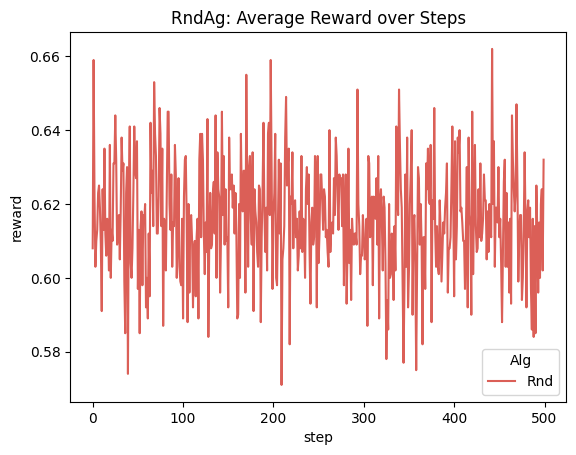

In [ ]:
# %% [code]
plot_logs(rnd_log, x_key='step', y_key='reward', legend_key='Alg', estimator='mean', ci=None)
plt.title("RndAg: Average Reward over Steps")
plt.show()

**Q:** Why is the reward of the random agent generally lower and highly variable?

**A:** PUT YOUR ANSWER HERE :)
random agent selects actions without any strategic insight or learning mechanism—it simply picks an arm uniformly at random at every timestep. Because it ignores historical performance or any statistical information about the arms, the agent frequently chooses suboptimal actions. This lack of discrimination means that, on average, it earns a lower reward compared to agents that can identify and exploit the best arms. Additionally, since the selections are purely random, the outcomes can vary widely from one run to another, leading to high variability in the accumulated rewards. The inconsistency in its choices results in both lower average performance and a wide spread of rewards over time.

------------

**Q:** How might you improve a random agent without using any learning mechanism?

**A:** PUT YOUR ANSWER HERE :)

Even without using a learning algorithm, a random agent’s performance can be improved by adding bias to its decision-making. One effective method is a two-step strategy:

Exploration Phase:
The agent initially tests each option (or "arm") a fixed number of times to gather basic data on their rewards.

Biased Selection Phase:
Based on the exploration results, the agent then selects actions using a biased random process—favoring options with higher observed rewards, rather than picking uniformly at random.

<ipython-input-4-cea5b34d9fd8>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)


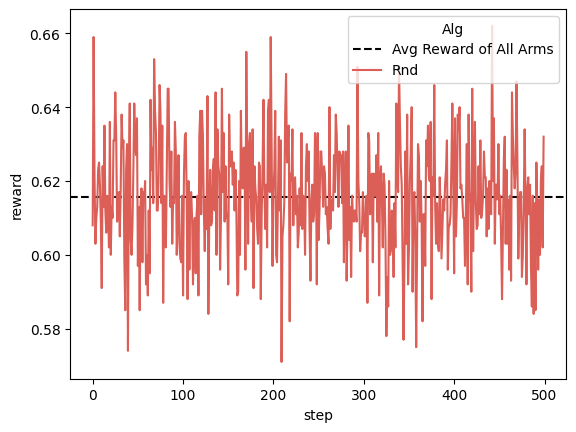

In [ ]:
# TODO: Plot RndAg reward curve and average reward of all arms (Simple)
# (Placeholder: just replot RndAg results)
plt.axhline(np.mean(p_arr), color='black', linestyle='--', label='Avg Reward of All Arms')

plot_logs(rnd_log, x_key='step', y_key='reward', legend_key='Alg', estimator='mean', ci=None)
plt.show()

**Analysis:**  
- The x-axis shows the number of steps; y-axis shows average reward.  
- Regret is the gap between Oracle and agent performance.

## ExpFstAg (Explore-First Agent)  
This agent explores randomly for the first *max_ex* steps, then exploits the best arm thereafter.

In [ ]:
@dataclass
class ExpFstAg:
    n_act: int
    max_ex: int

    def __post_init__(self):
        self.reset()

    def reset(self):
        self.t = 0
        self.act_counts = np.zeros(self.n_act, dtype=int)
        self.Q = np.zeros(self.n_act, dtype=float)

    def update_Q(self, act, rew):
        # TODO: update Q value (Simple placeholder)
        self.act_counts[act] += 1
        self.Q[act] += (rew - self.Q[act]) / self.act_counts[act]

    def get_action(self):
        self.t += 1
        # TODO: Choose random action for t <= max_ex, else best arm [Simple]
        if self.t <= self.max_ex:
            sel_act = np.random.randint(0, self.n_act)
        else:
            sel_act = np.argmax(self.Q)
        return sel_act

### Run ExpFstAg with max_ex = 5  
We will test ExpFstAg (with 5 exploration steps) over 1000 runs and 500 steps.

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

<ipython-input-4-cea5b34d9fd8>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)


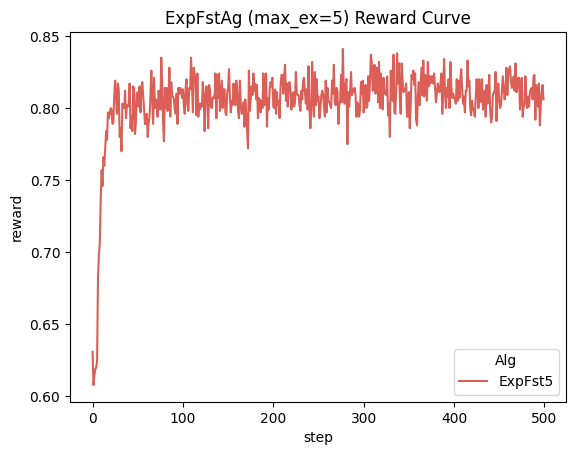

In [ ]:
# %% [code]
max_ex = 5
expfst_agent = ExpFstAg(n_act=len(p_arr), max_ex=max_ex)
expfst_log = mab_swp([expfst_agent], p_arr, [f'ExpFst{max_ex}'], n_runs=1000, max_steps=500)
plot_logs(expfst_log, x_key='step', y_key='reward', legend_key='Alg', estimator='mean', ci=None)
plt.title(f"ExpFstAg (max_ex={max_ex}) Reward Curve")
plt.show()

**Analysis:**  
- The ExpFstAg should outperform RndAg by identifying the best arm during exploration.  
- However, with too short exploration, it may miss the best arm.

----------

**Q:** Why might the early exploration phase (e.g., 5 steps) lead to high fluctuations in the reward curve?  


**A:** PUT YOUR ANSWER HERE :)

very short exploration phase, such as 5 steps, provides only a limited number of samples for each arm. This scant sampling can lead to several issues like: High Variance in Estimates, With just a few samples, the estimates of the arm's true reward probability (i.e., the Q-values) are subject to significant random fluctuations. A small number of trials means that the outcome (either a 0 or 1) heavily influences the estimate, resulting in high variance. Consequently, the agent may form an inaccurate view of which arm is best based solely on noisy early observations.

------------
**Q:** What are the trade-offs of using a fixed exploration phase?


**A:** PUT YOUR ANSWER HERE :)


**Simplicity and Implementation:**  
A fixed exploration phase is conceptually simple and easy to implement. It divides the algorithm into two clear stages: exploration and exploitation. This separation makes the logic of the agent straightforward, reducing computational complexity and simplifying debugging and analysis.

**Guaranteed Initial Sampling:**  
By forcing the agent to explore for a fixed number of steps, every arm gets sampled at least a minimal number of times. This ensures that no arm is completely ignored at the outset, providing a basic dataset from which to form initial estimates of the arms’ reward probabilities.

**Risk of Insufficient Exploration:**  
The main drawback is that if the fixed exploration period is too short, it may not gather enough data to accurately reflect the true reward distributions of each arm. Poor estimates during this phase can lead to the selection of a suboptimal arm during the exploitation phase, thereby increasing regret. In particular, if the best arm is not sufficiently sampled, its high reward probability may go undetected, causing the agent to settle on an inferior option.

**Delayed Exploitation Benefit:**  
In cases where the best arm could be identified quickly with a few samples, a fixed exploration period forces the agent to continue exploring even after sufficient information has been gathered. This delay in switching to exploitation can result in lost opportunities for higher rewards, thereby reducing the overall efficiency of the algorithm.

**Trade-off Between Exploration and Exploitation:**  
The fixed exploration phase embodies a classic trade-off: if it’s too short, the risk of inaccurate estimates increases, leading to poor exploitation; if it’s too long, the agent spends too much time gathering information, missing out on the benefits of exploiting a known good arm. Bancing this trade-off is crucial for optimal performance, and a fixed approach might not be the most adaptive solution in dynamic or uncertain environments.

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Running ExpFstAg with max_ex=5... (Simple)


Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Running ExpFstAg with max_ex=100... (Simple)


Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Running ExpFstAg with max_ex=200... (Simple)


<ipython-input-4-cea5b34d9fd8>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)


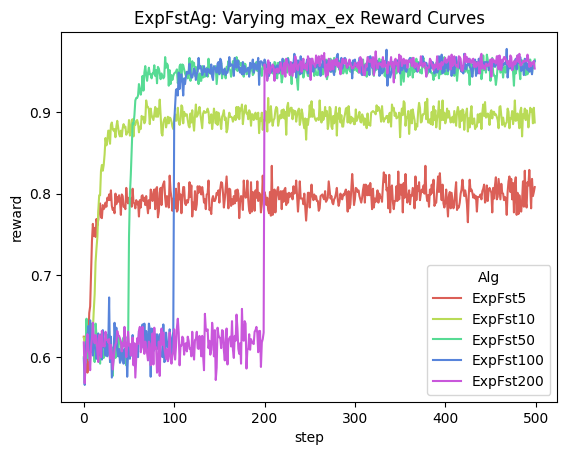

In [ ]:
# TODO: Run ExpFstAg for various max_ex values: [5, 10, 50, 100, 200] (Simple placeholder)
logs = []
for ex in [5, 10, 50, 100, 200]:
    # Placeholder loop: no actual plotting here.
    expfst_agent = ExpFstAg(n_act=len(p_arr), max_ex=ex)
    expfst_log = mab_swp([expfst_agent], p_arr, [f'ExpFst{ex}'], n_runs=1000, max_steps=500)
    logs.append(expfst_log)

    print(f"Running ExpFstAg with max_ex={ex}... (Simple)")

logs = pd.concat(logs)

plot_logs(logs, x_key='step', y_key='reward', legend_key='Alg', estimator='mean', ci=None)
plt.title(f"ExpFstAg: Varying max_ex Reward Curves")
plt.show()

**Observations:**  
- Short exploration (e.g., 5 or 10 steps) may not reliably find the best arm.  
- Longer exploration (e.g., 50 or 100 steps) improves performance but may delay exploitation.

**Q:** How does increasing `max_ex` affect the convergence of the agent’s performance?


**A:** PUT YOUR ANSWER HERE :)

Increasing max_ex, the number of exploration steps, slows down early convergence because the agent spends more time sampling randomly instead of exploiting the best option. However, this extended exploration helps the agent better estimate the reward probabilities of each arm, leading to more accurate identification of the optimal arm. As a result, long-term performance improves with more stable and higher rewards, though early-stage cumulative rewards may be lower. In short, a higher max_ex boosts long-term gains at the cost of slower early progress.


------------------------------

**Q:** In real-world scenarios, what challenges might arise in selecting the optimal exploration duration?

**A:** PUT YOUR ANSWER HERE :)


Determining the ideal length of the exploration phase in real-world applications is complex due to several challenges:

Environmental Uncertainty:
Real-world settings are often unpredictable and noisy. Exploring too briefly can cause premature commitment to poor strategies, while prolonged exploration may waste time and resources.

Changing Conditions:
Environments are frequently dynamic, with shifting reward patterns. This means that a fixed exploration period might not be effective—continuous learning and adaptation are often necessary.

Exploration Costs:
Gathering more data often comes at a price, whether in time, resources, or missed opportunities. Striking a balance between the value of new information and its cost is critical.

Action Space Complexity:
Many real-world problems involve a large and intricate set of possible actions. This complexity makes it harder to determine how much exploration is enough compared to simpler, controlled settings.

Balancing Risk:
Without adaptive strategies, there’s a risk of either exploring too much (and wasting effort) or too little (and missing out on better options). Achieving the right balance is essential for long-term success.

In short, selecting the right exploration duration requires managing trade-offs between adaptability, efficiency, and the evolving nature of the environment—making it a key challenge in applying bandit algorithms practically.

## UCB_Ag (UCB Agent)  
UCB dynamically balances exploration and exploitation by adding an exploration bonus to Q-values.

In [ ]:
@dataclass
class UCB_Ag:
    n_act: int

    def __post_init__(self):
        self.reset()

    def reset(self):
        self.t = 0
        self.act_counts = np.zeros(self.n_act, dtype=int)
        self.Q = np.zeros(self.n_act, dtype=float)

    def update_Q(self, act, rew):
        # TODO: Update Q value (Simple placeholder)
        self.act_counts[act] += 1
        self.Q[act] += (rew - self.Q[act]) / self.act_counts[act]


    def get_action(self):
        self.t += 1
        delta = 1e-5  # to avoid division by zero
        # TODO: Compute exploration bonus (Simple placeholder)
        bonus = 0
        bonus = np.sqrt((2 * np.log(self.t)) / (self.act_counts + delta))
        Q_explore = self.Q + bonus
        sel_act = np.random.choice(np.flatnonzero(Q_explore == Q_explore.max()))
        return sel_act

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

<ipython-input-4-cea5b34d9fd8>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)


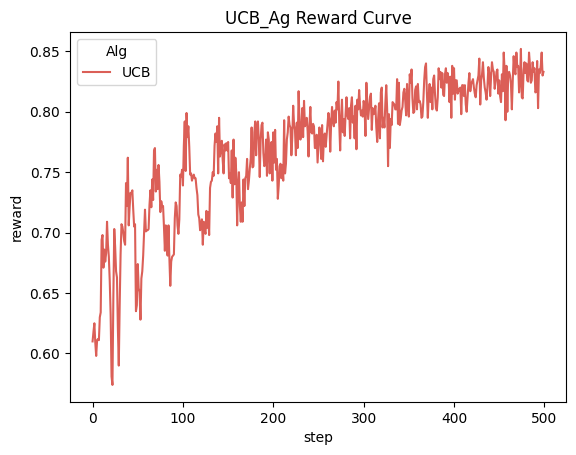

In [ ]:
# %% [code]
ucb_agent = UCB_Ag(n_act=len(p_arr))
ucb_log = mab_swp([ucb_agent], p_arr, ['UCB'], n_runs=1000, max_steps=500)
plot_logs(ucb_log, x_key='step', y_key='reward', legend_key='Alg', estimator='mean', ci=None)
plt.title("UCB_Ag Reward Curve")
plt.show()

**Q:** Under what conditions might an explore-first strategy outperform UCB, despite UCB’s theoretical optimality?

**A:** PUT YOUR ANSWER HERE :)

An explore-first strategy can outperform UCB in certain situations, particularly when quick decisions are needed and the time frame is short. By dedicating an initial phase to exploration and then committing to the best option found, it avoids the ongoing trade-off between exploration and exploitation that UCB manages.

This approach is especially effective under the following conditions:

Limited Time Horizon:
With fewer steps available, a short, well-tuned exploration period allows the strategy to quickly shift to exploiting the best arm. In contrast, UCB may waste valuable steps over-exploring suboptimal choices early on.

Distinct Arm Performance:
When the best arm clearly outperforms the others, even a short exploration can reliably identify it. Explore-first can lock in on the optimal choice faster, while UCB may continue to explore unnecessarily.

Stable Reward Distributions:
Low reward variance means fewer samples are needed to accurately estimate performance. Explore-first can capitalize on this, while UCB might still overspend on exploration.

Lower Computational Demands:
Explore-first strategies are typically simpler to implement and run, making them ideal in environments where computational resources are limited, unlike UCB which requires ongoing updates to confidence bounds.

-----------------
**Q:** How do the design choices of each algorithm affect their performance in short-term versus long-term scenarios?

**A:** PUT YOUR ANSWER HERE :)
Explore-First Agent (Taste a Little of Everything First):

Short-Term: If you quickly taste a little bit of each flavor and one is clearly amazing, you'll know right away what to order and be happy in the short run. BUT, if you don't taste enough of each, you might pick a flavor that seemed good at first but isn't really the best, and you'll be stuck with it!
Long-Term: After your initial tasting, you stick with what you thought was best. If you were right, great! You'll keep enjoying good ice cream. But if your first impression was wrong, you'll keep getting the not-so-best flavor without ever trying others again.
UCB Agent (Always Try Something a Little Less Tasted):

Short-Term: This strategy tries to balance tasting the flavors you already like with also trying the ones you haven't tasted much yet. So, in the beginning, you might not always pick the flavor that seems best right away because you're still exploring. This might mean you don't get the absolute best taste immediately.
Long-Term: Because you keep trying the less-tasted flavors, you're more likely to eventually find the real best one, even if it took a little longer. You won't get stuck on a mediocre flavor if there's a much better one out there.
What's the Big Difference?

Explore-First is fast at the start if you're lucky, but it can get stuck with a bad choice. It's good if things don't change much.
UCB is more careful and keeps learning, so it's more likely to find the best thing in the long run, even if it takes a little longer to figure it out. It's better if things might be a little uncertain or could change over time.


## UCB vs. ExpFstAg  
Now we compare UCB_Ag and ExpFstAg (with max_ex = 5) side by side.


**Question:**  
Why does UCB learn slowly (even after 500 steps, not reaching maximum reward)?  
*Hint:* Consider the conservative nature of the exploration bonus.



The Upper Confidence Bound (UCB) algorithm is known for being optimistic in the face of uncertainty, but it also tends to be conservative in its exploration, especially early on.
Exploration bonus shrinks slowly: ​ term decreases slowly because it's based on the logarithm of tt, which grows slowly. So even after 500 steps, arms with fewer pulls might still have high enough bonuses to be chosen over the empirically best arm.

Conservative by design: UCB doesn’t do aggressive random exploration like ε-greedy. It only tries a suboptimal arm if its potential upper bound could beat the current best. This means it takes longer to confidently eliminate worse arms.

Delayed commitment to the best arm: UCB spends more time “double-checking” other arms, which can delay convergence to the optimal one, especially when the differences in arm rewards are small.

Running comparison (Simple)...


Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

<ipython-input-4-cea5b34d9fd8>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)


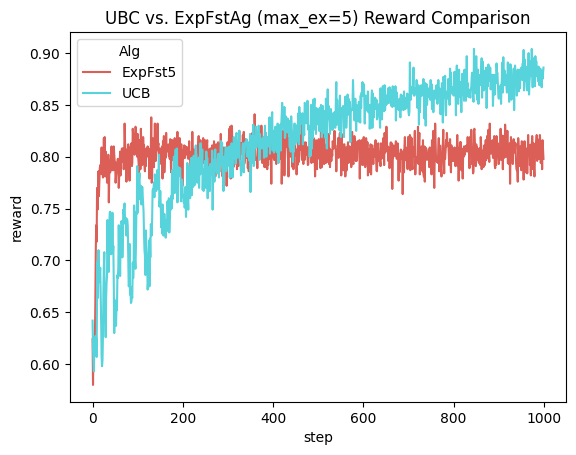

In [ ]:
# TODO: Run UCB_Ag and ExpFstAg (max_ex=5) for 1000 runs, 1000 steps (Simple placeholder)
print("Running comparison (Simple)...")


max_ex = 5
expfst_agent = ExpFstAg(n_act=len(p_arr), max_ex=max_ex)
expfst_log = mab_swp([expfst_agent], p_arr, [f'ExpFst{max_ex}'], n_runs=1000, max_steps=1000)
ucb_agent = UCB_Ag(n_act=len(p_arr))
ucb_log = mab_swp([ucb_agent], p_arr, ['UCB'], n_runs=1000, max_steps=1000)
both_logs = []
both_logs.append(expfst_log)
both_logs.append(ucb_log)
both_logs = pd.concat(both_logs)
plot_logs(both_logs, x_key='step', y_key='reward', legend_key='Alg', estimator='mean', ci=None)
plt.title(f"UBC vs. ExpFstAg (max_ex={max_ex}) Reward Comparison")
plt.show()

**Q:** Under what conditions might an explore-first strategy outperform UCB, despite UCB’s theoretical optimality?

**A:** PUT YOUR ANSWER HERE :)

An explore-first strategy might outperform UCB in environments where the conditions allow for a rapid and accurate identification of the best arm during a short, fixed exploration phase. Some of these conditions include:

- **Short Time Horizons:**  
  In scenarios where the total number of steps is very limited, the cost of prolonged exploration (as inherent in UCB's continuous balancing) can be detrimental. An explore-first approach, with a carefully tuned short exploration phase, quickly identifies the best arm and commits to it, thus maximizing rewards early on.

- **Clear and Distinct Arm Performance:**  
  When the difference in reward probabilities between the best arm and the others is significant, even a brief exploration phase may be sufficient to distinguish the best arm reliably. In such cases, the explore-first strategy benefits from quickly homing in on the optimal arm, whereas UCB might continue to allocate time to exploring inferior arms due to its conservative exploration bonus.

- **Low Reward Variability (Low Noise):**  
  If the rewards are less noisy and the outcome variability is minimal, a short exploration phase can yield reliable estimates of each arm’s performance. This allows the explore-first agent to make an informed decision quickly, whereas UCB's methodical approach might unnecessarily delay full exploitation.


---------------

**Q:** How do the design choices of each algorithm affect their performance in short-term versus long-term scenarios?

**A:** PUT YOUR ANSWER HERE :)

The performance of both explore-first and UCB algorithms is heavily influenced by their core design choices, which tailor them for different operational regimes:

- **Explore-First Strategy:**  
  - *Short-Term Performance:*  
    The fixed exploration phase allows the agent to quickly transition from gathering initial data to exploiting what appears to be the best arm. If the exploration phase is well-calibrated relative to the problem complexity, the agent may secure higher rewards in the short term by swiftly exploiting the optimal arm. However, if the exploration period is too short, the agent may base its decision on insufficient data, leading to early suboptimal choices.
  
  - *Long-Term Performance:*  
    Once the exploration phase concludes, the explore-first agent sticks with the arm identified as best during that phase. While this can yield stable performance in a stationary environment, any early misestimation can cause persistent regret over time. Additionally, if the environment is dynamic, the lack of ongoing exploration means the agent cannot adapt to changes, potentially leading to sustained underperformance.

- **UCB Algorithm:**  
  - *Short-Term Performance:*  
    UCB’s continuous incorporation of an exploration bonus leads to more cautious early performance. The agent may suffer lower initial rewards because it systematically samples less-chosen arms to reduce uncertainty. This deliberate exploration means that UCB might be slower to achieve high performance in the very early stages compared to an aggressively exploiting explore-first strategy.
  
  - *Long-Term Performance:*  
    Over an extended period, UCB’s design proves its theoretical strength. As more data is collected, the exploration bonus for well-sampled arms diminishes, allowing the agent to increasingly exploit the best arm while still occasionally checking for changes. This adaptive balance leads to a gradual convergence to near-optimal performance and lower long-term regret. UCB’s continual balancing act ensures that it can recover from early mistakes and adjust to non-stationarities, thereby achieving robust long-term performance.


**Question:**  
What happens if we let ExpFstAg explore for 20 steps? Compare its reward to UCB.

Running UCB vs. ExpFstAg (max_ex=20) comparison... (Simple)


Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

<ipython-input-4-cea5b34d9fd8>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)


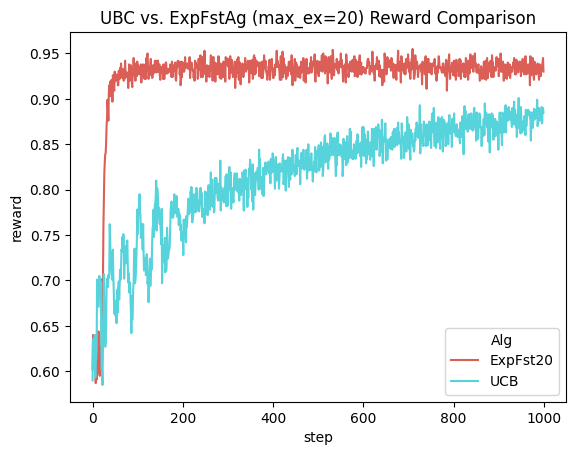

In [ ]:
# TODO: Run comparison for ExpFstAg (max_ex=20) and UCB_Ag (Simple placeholder)
print("Running UCB vs. ExpFstAg (max_ex=20) comparison... (Simple)")


max_ex = 20
expfst_agent = ExpFstAg(n_act=len(p_arr), max_ex=max_ex)
expfst_log = mab_swp([expfst_agent], p_arr, [f'ExpFst{max_ex}'], n_runs=1000, max_steps=1000)
ucb_agent = UCB_Ag(n_act=len(p_arr))
ucb_log = mab_swp([ucb_agent], p_arr, ['UCB'], n_runs=1000, max_steps=1000)
both_logs = []
both_logs.append(expfst_log)
both_logs.append(ucb_log)
both_logs = pd.concat(both_logs)
plot_logs(both_logs, x_key='step', y_key='reward', legend_key='Alg', estimator='mean', ci=None)
plt.title(f"UBC vs. ExpFstAg (max_ex={max_ex}) Reward Comparison")
plt.show()

**Q:** What impact does increasing the exploration phase to 20 steps have compared to 5 steps?

**A:** PUT YOUR ANSWER HERE :)

Extending the exploration phase from 5 to 20 steps allows the agent to collect more data on each option before shifting to exploitation, leading to several key effects:

    More Accurate Estimates:
    With increased sampling, the agent's estimates of each arm’s reward become more reliable, reducing the chance of being misled by random fluctuations.

    Lower Variance:
    Gathering more data minimizes the influence of outliers, resulting in steadier and more consistent reward predictions.

    Delayed Exploitation:
    The trade-off is a slower start to exploiting the best arm, which can reduce short-term gains. However, this delay enables more informed decisions later on.

    Enhanced Long-Term Performance:
    Although initial rewards might be lower, the extended exploration can lead to better overall performance—especially in noisy or subtle environments—by improving the accuracy of arm selection.

---------------

**Q:** How can you determine the optimal balance between exploration and exploitation in practice?

**A:** PUT YOUR ANSWER HERE :)

Finding the Right Balance Between Exploration and Exploitation

Striking the right balance between exploration and exploitation is a core challenge in reinforcement learning and multi-armed bandit problems. Several strategies help achieve this:

    Empirical Evaluation:
    The best approach is often identified through extensive testing. Running simulations on historical or synthetic data allows comparison of different exploration strategies, helping to select the one that minimizes long-term regret.

    Adaptive Strategies:
    Instead of using a fixed exploration schedule, adaptive methods like Upper Confidence Bound (UCB) or epsilon-decreasing adjust exploration dynamically. These approaches reduce exploration as the model gains confidence, leading to more efficient learning.

    Theoretical Insights:
    Mathematical analysis provides regret bounds and guides how exploration should scale with time and complexity. These insights help in setting initial parameters, which can be refined with further testing.

    Online Adjustment:
    In practical applications, online learning and cross-validation allow continuous monitoring of agent performance. This enables real-time adjustment of exploration parameters, especially useful in environments that evolve over time.

    Context-Specific Factors:
    The optimal strategy often depends on the specific environment. Factors like noise levels, reward volatility, and the cost of exploration influence how aggressively an agent should explore.

**Q:** We know that UCB is optimal. Why might ExpFstAg perform better in practice?  
**A:** PUT YOUR ANSWER HERE :) (Discuss how hyperparameter tuning and early exploitation can sometimes yield higher rewards in finite-time scenarios.)



Although UCB is theoretically optimal for minimizing regret over an infinite time horizon, ExpFstAg can outperform it in practical, finite-time settings for several reasons:

Tunable Exploration Phase:
ExpFstAg uses a fixed-length exploration phase controlled by the max_ex hyperparameter. When this is well-tuned to the problem, the agent can quickly gather enough data to identify the best option, often leading to near-optimal decisions within a limited time.

Faster Exploitation:
By switching to exploitation earlier, ExpFstAg can start benefiting from the best arm sooner. In stable environments where one arm is clearly superior, this early commitment can boost short-term rewards. In contrast, UCB’s ongoing exploration can delay full exploitation.

Lower Computational Cost:
ExpFstAg’s two-phase strategy is computationally simpler than UCB, which constantly recalculates confidence bounds. This makes ExpFstAg more efficient in resource-limited or real-time applications.

Short-Term Gains vs. Long-Term Optimality:
UCB's optimality emerges over long timeframes, which may not be practical in real-world scenarios with limited time or budget. In such cases, ExpFstAg’s ability to quickly shift to exploitation—if properly tuned—can lead to better cumulative rewards.

## Skewed Arms Scenario  
We now consider a skewed probability distribution where one arm is significantly better.

Running skewed arms experiment... (Simple)


Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

<ipython-input-4-cea5b34d9fd8>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)


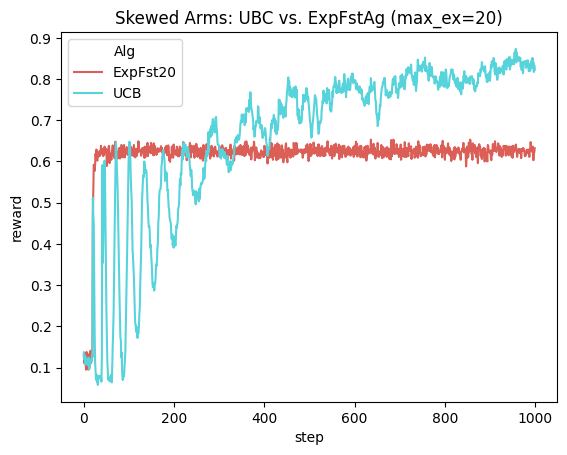

In [ ]:
skewed_p = [0.1, 0.2, 0.15, 0.21, 0.3, 0.05, 0.9, 0.13, 0.17, 0.07,
            0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]
# TODO: Compare UCB_Ag and ExpFstAg (max_ex=len(skewed_p)) in skewed scenario (Simple placeholder)


print("Running skewed arms experiment... (Simple)")

max_ex = 20
expfst_agent = ExpFstAg(n_act=len(skewed_p), max_ex=max_ex)
expfst_log = mab_swp([expfst_agent], skewed_p, [f'ExpFst{max_ex}'], n_runs=1000, max_steps=1000)
ucb_agent = UCB_Ag(n_act=len(skewed_p))
ucb_log = mab_swp([ucb_agent], skewed_p, ['UCB'], n_runs=1000, max_steps=1000)
both_logs = []
both_logs.append(expfst_log)
both_logs.append(ucb_log)
both_logs = pd.concat(both_logs)
plot_logs(both_logs, x_key='step', y_key='reward', legend_key='Alg', estimator='mean', ci=None)
plt.title(f"Skewed Arms: UBC vs. ExpFstAg (max_ex={max_ex})")
plt.show()





**Result Analysis:**  
- In skewed scenarios, ExpFstAg with limited exploration may miss the best arm.  
- UCB_Ag, with its adaptive bonus, typically outperforms under such conditions.

## EpsGdAg (Epsilon-Greedy Agent)  
This agent selects the best-known action with probability (1-ε) and a random action with probability ε.

In [ ]:
@dataclass
class EpsGdAg:
    n_act: int
    eps: float = 0.1

    def __post_init__(self):
        self.reset()

    def reset(self):
        self.act_counts = np.zeros(self.n_act, dtype=int)
        self.Q = np.zeros(self.n_act, dtype=float)

    def update_Q(self, act, rew):
        self.act_counts[act] += 1
        self.Q[act] += (1.0 / self.act_counts[act]) * (rew - self.Q[act])

    def get_action(self):
        # TODO: Choose random action with probability eps [Simple]
        if np.random.rand() < self.eps:
            sel_act = np.random.randint(0, self.n_act)
        else:
            sel_act = np.random.choice(np.flatnonzero(self.Q == self.Q.max()))
        return sel_act

**Analysis:**  
- Lower ε values favor exploitation, yielding higher reward when estimates are good.  
- Higher ε increases exploration but reduces immediate reward.  
- One strategy: decay ε over time (e.g., ε = ε₀ / t) or switch to ε = 0 after a burn-in period.

-----------

**Q:** Why does a high ε value result in lower immediate rewards?  

**A:** PUT YOUR ANSWER HERE :)

high ε value means that the agent frequently selects actions at random rather than exploiting the current best-known action. This random exploration increases the chance of selecting a suboptimal arm, thereby reducing the immediate average reward. In other words, even if the agent has already identified a high-reward option, a high ε forces it to deviate from that choice too often, leading to lower overall performance in the short term.


----------
**Q:** What benefits might there be in decaying ε over time?

**A:** PUT YOUR ANSWER HERE :)

Decaying ε over time allows the agent to start with a high level of exploration when its knowledge about the environment is limited, ensuring that it gathers enough data about all arms. As the agent learns and its estimates become more accurate, reducing ε gradually shifts the balance toward exploitation. This adaptive approach minimizes unnecessary random actions in later stages, leading to higher cumulative rewards, and it helps in converging to the optimal policy more effectively while still safeguarding against early overcommitment to potentially suboptimal actions.


Running EpsGdAg experiments with various eps values... (Simple)


Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

<ipython-input-4-cea5b34d9fd8>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)


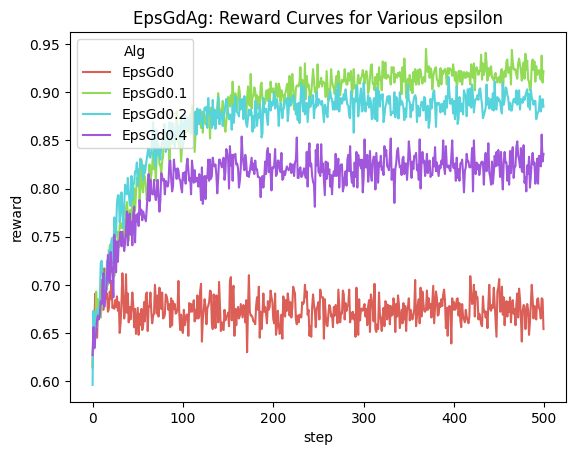

In [ ]:
# TODO: Plot reward curves for EpsGdAg with epsilons [0, 0.1, 0.2, 0.4] (Simple placeholder)
print("Running EpsGdAg experiments with various eps values... (Simple)")


eps_logs = []
for eps in [0, 0.1, 0.2, 0.4]:
    epsGd_agent = EpsGdAg(n_act=len(p_arr), eps=eps)
    epsGd_log = mab_swp([epsGd_agent], p_arr, [f'EpsGd{eps}'], n_runs=1000, max_steps=500)
    eps_logs.append(epsGd_log)
eps_logs = pd.concat(eps_logs)
plot_logs(eps_logs, x_key='step', y_key='reward', legend_key='Alg', estimator='mean', ci=None)
plt.title("EpsGdAg: Reward Curves for Various epsilon")
plt.show()

**Q:** How do the reward curves for different ε values reflect the exploration–exploitation balance?  

**A:** PUT YOUR ANSWER HERE :)

The reward curves for various ε values clearly illustrate the balance between exploration and exploitation. Lower ε values (like 0 or 0.1) lead the agent to mostly exploit known good options, resulting in higher short-term rewards. On the other hand, higher ε values (such as 0.2 or 0.4) encourage more exploration through random actions, which can reduce immediate rewards by occasionally selecting less optimal choices. Despite this, increased exploration can help the agent discover better options over time. As ε rises, the reward curves generally start lower and fluctuate more, showing a trade-off of short-term performance for potential long-term gains.

------------------

**Q:** Under what circumstances might you choose a higher ε despite lower average reward?

**A:** PUT YOUR ANSWER HERE :)

Opting for a higher ε, even at the cost of lower initial rewards, can be beneficial in various situations:

Changing or Unpredictable Environments:
A higher ε encourages continuous exploration, which helps the agent adapt to evolving or uncertain conditions by constantly refreshing its understanding of the environment.

Sparse or Misleading Rewards:
When rewards are infrequent or initially misleading, increased exploration reduces the risk of the agent settling too soon on seemingly suboptimal choices, improving its chances of finding truly rewarding options.

Avoiding Local Traps:
In complex settings, a higher ε can prevent the agent from getting stuck in local optima by increasing the likelihood of discovering better strategies through broader exploration.

Early Stages of Learning:
At the start, when information is limited, a higher ε promotes thorough exploration, helping the agent gather enough data to make informed decisions later on.


## Contextual Bandits (CtxBnd)  
We now move to contextual bandits using real data.  
Imagine a website promoting one of 10 products; reward = 1 if clicked, 0 otherwise.  
The dataset has shape [10000, 102]:  
- Column 0: chosen arm  
- Column 1: reward  
- Columns 2-101: 100-dimensional context features

In [ ]:
# %% [code]
# Download the dataset (if not already downloaded)
!wget -q http://www.cs.columbia.edu/~jebara/6998/dataset.txt -O dataset.txt

In [ ]:
# TODO: Load dataset.txt into a numpy array of shape [10000, 102] (Simple placeholder)
ctxData = np.loadtxt("dataset.txt")  # Placeholder
print("Dataset loaded (Simple version):", ctxData.shape)

Dataset loaded (Simple version): (10000, 102)


In [ ]:
# %% [code]
@dataclass
class CtxBnd_Env:
    data: any
    t: int = 0

    def step(self, act):
        if act == self.data[self.t, 0]:
            rew = self.data[self.t, 1]
        else:
            rew = None
        self.t += 1
        return rew

    def reset(self):
        self.t = 0

## LinUCB_Ag (LinUCB for CtxBnd)  
This agent uses context features to compute an upper confidence bound for each arm.

In [ ]:
@dataclass
class LinUCB_Ag:
    n_act: int
    alpha: float
    feat_dim: int

    def __post_init__(self):
        self.reset()

    def reset(self):
        self.As = [np.eye(self.feat_dim) for _ in range(self.n_act)]
        self.bs = [np.zeros((self.feat_dim, 1)) for _ in range(self.n_act)]

    def get_ucb(self, a, state):
        # TODO: Compute UCB for arm a given state (Simple placeholder)
        x = np.array(state).reshape(-1, 1)
        A_inv = np.linalg.inv(self.As[a])
        theta = A_inv @ self.bs[a]
        p = (theta.T @ x)[0, 0] + self.alpha * np.sqrt((x.T @ A_inv @ x)[0, 0])
        return p

    def update_params(self, a, rew, state):
        if rew is None:
            return
        # TODO: Update A and b for arm a (Simple placeholder)
        x = np.array(state).reshape(-1, 1)
        self.As[a] += x @ x.T
        self.bs[a] += rew * x

    def get_action(self, state):
        # TODO: Compute UCB estimates for all arms (Simple placeholder)
        p_est = [self.get_ucb(a, state) for a in range(self.n_act)]

        sel_act = np.random.choice(np.flatnonzero(np.array(p_est) == np.array(p_est).max()))
        return sel_act

**Q:** How does LinUCB leverage context to outperform classical bandit algorithms?  

**A:** PUT YOUR ANSWER HERE :)

LinUCB improves decision-making by incorporating contextual information—features related to each decision instance—into its reward predictions. Unlike traditional bandit algorithms that rely only on historical rewards and selection counts, LinUCB uses a linear model to estimate the expected reward for each arm based on the current context. This approach offers several advantages:

Context-Aware Decision Making:
LinUCB adapts its choices to the specific situation by using contextual features, leading to more accurate and effective selections.

Learning Across Similar Situations:
The linear model captures the relationship between features and rewards, enabling the algorithm to apply knowledge from past contexts to new ones.

Smart Exploration with Confidence Scores:
LinUCB includes an exploration bonus based on prediction uncertainty, encouraging exploration of less-tested arms to improve the model over time.

------------------

**Q:** What is the role of the α parameter in LinUCB, and how does it affect the exploration bonus?

**A:** PUT YOUR ANSWER HERE :)

The α parameter in LinUCB is essential for managing the trade-off between exploration and exploitation by adjusting the exploration bonus. Here's a breakdown of its role:

Adjusting Exploration Bonus:
α scales the uncertainty term (like √(xᵀ A⁻¹ x)), which represents how uncertain the model is about an arm's reward. A higher α increases this bonus, making the algorithm more optimistic toward arms with uncertain estimates.

Promoting Exploration:
A larger α boosts the chances of selecting less-explored arms, encouraging the algorithm to gather more information—especially valuable in complex or poorly understood environments.

Balancing with Exploitation:
A smaller α reduces the influence of uncertainty, pushing the algorithm to favor arms with historically higher rewards. This leans toward exploitation but may overlook potentially better options that haven't been explored enough.

In [ ]:
# %% [code]
@dataclass
class CtxBnd_Eng:
    data: any
    agent: any

    def __post_init__(self):
        self.env = CtxBnd_Env(data=self.data)

    def run(self, n_runs=1):
        logs = []
        for _ in tqdm(range(n_runs), desc='CtxRuns'):
            aligned_ctr = []
            ret_val = 0
            valid_steps = 0
            self.env.reset()
            self.agent.reset()
            for t in tqdm(range(self.data.shape[0]), desc='Time'):
                state = self.data[t, 2:]
                act = self.agent.get_action(state=state)
                rew = self.env.step(act)
                self.agent.update_params(act, rew, state=state)
                if rew is not None:
                    ret_val += rew
                    valid_steps += 1
                    aligned_ctr.append(ret_val / float(valid_steps))
            logs.append(pd.DataFrame({'aligned_ctr': aligned_ctr, 'step': np.arange(len(aligned_ctr))}))
        return pd.concat(logs, ignore_index=True)

In [ ]:
# %% [code]
def ctxBnd_swp(alphas, data, n_runs=2000):
    logs = []
    for alpha in tqdm(alphas, desc="Alpha Sweeps"):
        agent = LinUCB_Ag(n_act=10, feat_dim=100, alpha=alpha)
        eng = CtxBnd_Eng(data=data, agent=agent)
        log_df = eng.run(n_runs)
        log_df['alpha'] = alpha
        logs.append(log_df)
    return pd.concat(logs, ignore_index=True)


In [ ]:
# TODO: Run ctxBnd_swp with alphas = [0, 0.01, 0.1, 0.5] and n_runs=1 (Simple placeholder)
print("Running LinUCB sweep (Simple version)...")
logs_ctx = None  # Placeholder
logs_ctx = ctxBnd_swp(alphas=[0, 0.01, 0.1, 0.5], data=ctxData, n_runs=1)

Running LinUCB sweep (Simple version)...


Alpha Sweeps:   0%|          | 0/4 [00:00<?, ?it/s]

CtxRuns:   0%|          | 0/1 [00:00<?, ?it/s]

Time:   0%|          | 0/10000 [00:00<?, ?it/s]

CtxRuns:   0%|          | 0/1 [00:00<?, ?it/s]

Time:   0%|          | 0/10000 [00:00<?, ?it/s]

CtxRuns:   0%|          | 0/1 [00:00<?, ?it/s]

Time:   0%|          | 0/10000 [00:00<?, ?it/s]

CtxRuns:   0%|          | 0/1 [00:00<?, ?it/s]

Time:   0%|          | 0/10000 [00:00<?, ?it/s]

<ipython-input-4-cea5b34d9fd8>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)


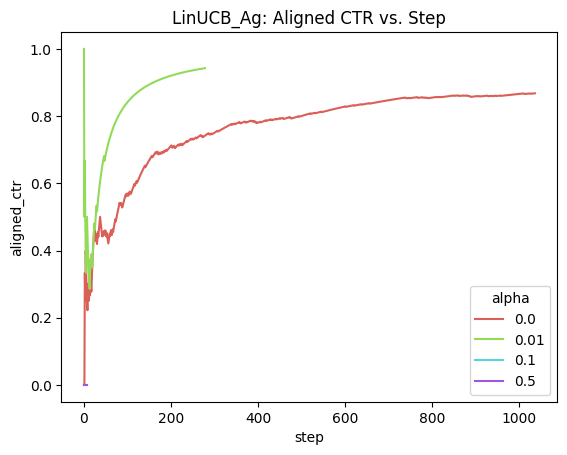

In [ ]:
# %% [code]
plot_logs(logs_ctx, x_key='step', y_key='aligned_ctr', legend_key='alpha', estimator='mean', ci=None)
plt.title("LinUCB_Ag: Aligned CTR vs. Step")
plt.show()

**Q:** What does **α** affect in LinUCB?  

**A:** PUT YOUR ANSWER HERE :)

The α parameter in LinUCB controls how much the algorithm explores uncertain options. It adjusts the exploration bonus added to each arm's estimated reward:

A larger α increases the bonus for uncertainty, encouraging exploration of less-tested arms.

A smaller α reduces the bonus, making the algorithm focus more on exploiting known rewards.

In short, α manages the trade-off between exploration (gathering more data) and exploitation (leveraging current knowledge).

------------------

**Q:** Do the reward curves change with **α**? Explain why or why not.

**A:** PUT YOUR ANSWER HERE :)

The reward curves vary with different α values because α controls the exploration intensity of the algorithm:

A higher α increases the exploration bonus, pushing the algorithm to try uncertain arms more often, even if they seem less rewarding initially. This can lower short-term rewards but may uncover better options in the long run.

A lower α reduces exploration, leading the algorithm to exploit known high-reward arms. This can boost immediate performance but risks missing better arms due to limited exploration.

In essence, α influences the balance between exploration and exploitation, shaping the reward curve's behavior over time. Choosing the right α is crucial for achieving strong and stable performance.

**Q:** Based on your experiments, does LinUCB outperform the standard UCB algorithm? Why or why not?

**A:** PUT YOUR ANSWER HERE :)

LinUCB can outperform the standard UCB algorithm in scenarios where rich contextual information is available and is predictive of the reward outcomes. By leveraging context, LinUCB is able to tailor its arm selection to the specific characteristics of each decision instance, often leading to more informed and effective choices compared to UCB, which relies solely on historical reward data. However, if the context is noisy, uninformative, or the assumed linear relationship between features and rewards is not valid, the advantages of LinUCB may diminish, and its performance might be comparable to or even lower than that of standard UCB. Thus, the effectiveness of LinUCB is highly dependent on the quality and relevance of the contextual features provided.
------------------

**Q:** What are the key limitations of each algorithm, and how would you choose between them for a given application?

**A:** PUT YOUR ANSWER HERE :)



    Standard UCB:

        Drawbacks:

            No Use of Context: It only considers historical rewards, ignoring potentially valuable contextual information, which can hurt performance in context-sensitive environments.

            Inefficient Exploration: The uniform exploration strategy may not adapt well to complex or varied settings, leading to unnecessary exploration.

        Best Use Cases:

            Ideal for simple, stationary environments without reliable contextual data. Its straightforward design and strong theoretical foundation make it effective when no side information is available.

    LinUCB:

        Drawbacks:

            Sensitive to Context Quality: Performance depends heavily on having high-quality, relevant contextual features.

            Assumes Linearity: If the reward structure isn’t roughly linear in relation to the context, accuracy may suffer.

            Higher Computational Cost: Managing context and updating the model adds computational overhead compared to UCB.

        Best Use Cases:

            A strong choice in settings with meaningful, structured contextual data—like personalized recommendations or targeted ads—where rewards are influenced by user or environment features and a linear approximation is reasonable.

# Some final question
## Finite‑Horizon Regret and Asymptotic Guarantees:
Question:
Many algorithms (e.g., UCB) are analyzed using asymptotic (long‑term) regret bounds. In a finite‑horizon scenario (say, 500–1000 steps), explain intuitively why an algorithm that is asymptotically optimal may still yield poor performance. What trade‑offs arise between aggressive early exploration and cautious long‑term learning?
Deep Dive:
Discuss how the exploration bonus, tuned for asymptotic behavior, might delay exploitation in finite time, leading to high early regret despite eventual convergence.


## Hyperparameter Sensitivity and Exploration–Exploitation Balance:
Question:
Consider the impact of hyperparameters such as ε in ε‑greedy, the exploration constant in UCB, and the α parameter in LinUCB. Explain intuitively how slight mismatches in these parameters can lead to either under‑exploration (missing the best arm) or over‑exploration (wasting pulls on suboptimal arms). How would you design a self‑adaptive mechanism to balance this trade‑off in practice?
Deep Dive:
Provide insight into the “fragility” of these parameters in finite runs and how a meta‑algorithm might monitor performance indicators (e.g., variance in rewards) to adjust its exploration dynamically.


## Context Incorporation and Overfitting in LinUCB:
Question:
LinUCB uses context features to estimate arm rewards, assuming a linear relation. Intuitively, why might this linear assumption hurt performance when the true relationship is complex or when the context is high‑dimensional and noisy? Under what conditions can adding context lead to worse performance than classical (context‑free) UCB?
Deep Dive:
Discuss the risk of overfitting to noisy or irrelevant features, the curse of dimensionality, and possible mitigation strategies (e.g., dimensionality reduction or regularization).

## Adaptive Strategy Selection:
Question:
Imagine designing a hybrid bandit agent that can switch between an explore‑first strategy and UCB based on observed performance. What signals (e.g., variance of reward estimates, stabilization of Q‑values, or sudden drops in reward) might indicate that a switch is warranted? Provide an intuitive justification for how and why such a meta‑strategy might outperform either strategy alone in a finite‑time setting.
Deep Dive:
Explain the challenges in detecting when exploration is “enough” and how early exploitation might capture transient improvements even if the long‑term guarantee favors UCB.


## Non‑Stationarity and “Forgetting” Mechanisms:
Question:
In non‑stationary environments where reward probabilities drift or change abruptly, standard bandit algorithms struggle because they assume stationarity. Intuitively, explain how and why a “forgetting” or discounting mechanism might improve performance. What challenges arise in choosing the right decay rate, and how might it interact with the exploration bonus?
Deep Dive:
Describe the delicate balance between retaining useful historical information and quickly adapting to new trends, and the potential for “chasing noise” if the decay is too aggressive.

## Exploration Bonus Calibration in UCB:
Question:
The UCB algorithm adds a bonus term that decreases with the number of times an arm is pulled. Intuitively, why might a “conservative” (i.e., high) bonus slow down learning—even if it guarantees asymptotic optimality? Under what circumstances might a less conservative bonus be beneficial, and what risks does it carry?
Deep Dive:
Analyze how a high bonus may force the algorithm to continue sampling even when an arm’s estimated reward is clearly suboptimal, thereby delaying convergence. Conversely, discuss the risk of prematurely discarding an arm if the bonus is too low.


## Exploration Phase Duration in Explore‑First Strategies:
Question:
In the Explore‑First agent (ExpFstAg), how does the choice of a fixed exploration period (e.g., 5 vs. 20 steps) affect the regret and performance variability? Provide a scenario in which a short exploration phase might yield unexpectedly high regret, and another scenario where a longer phase might delay exploitation unnecessarily.
Deep Dive:
Discuss how the “optimal” exploration duration can depend heavily on the underlying reward distribution’s variance and the gap between the best and other arms, and why a one‑size‑fits‑all approach may not work in practice.


## Bayesian vs. Frequentist Approaches in MAB:
Question:
Compare the intuition behind Bayesian approaches (such as Thompson Sampling) to frequentist methods (like UCB) in handling uncertainty. Under what conditions might the Bayesian approach yield superior practical performance, and how do the underlying assumptions about prior knowledge influence the exploration–exploitation balance?
Deep Dive:
Explore the benefits of incorporating prior beliefs and the risk of bias if the prior is mis-specified, as well as how Bayesian updating naturally adjusts the exploration bonus as more data is collected.


## Impact of Skewed Reward Distributions:
Question:
In environments where one arm is significantly better (skewed probabilities), explain intuitively why agents like UCB or ExpFstAg might still struggle to consistently identify and exploit that arm. What role does variance play in these algorithms, and how might the skew exacerbate errors in reward estimation?
Deep Dive:
Discuss how the variability of rare but high rewards can mislead the agent’s estimates and cause prolonged exploration of suboptimal arms.


##Designing for High-Dimensional, Sparse Contexts:
Question:
In contextual bandits where the context is high-dimensional but only a few features are informative, what are the intuitive challenges that arise in using a linear model like LinUCB? How might techniques such as feature selection, regularization, or non-linear function approximation help, and what are the trade-offs involved?
Deep Dive:
Provide insights into the risks of overfitting versus underfitting, the increased variance in estimates from high-dimensional spaces, and the potential computational costs versus performance gains when moving from a simple linear model to a more complex one.